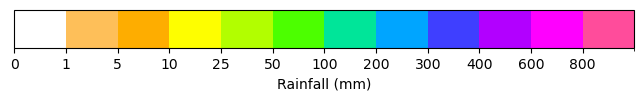

In [10]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

# Load the unique RGB values from CSV
csv_file = "/home/roddyb/projects/wheatbelt_rainfall_analyser/data/colormaps/unique_rgb_colors.csv"
df = pd.read_csv(csv_file)

# Define the boundaries based on rainfall intervals
boundaries = np.append(df["Rainfall"].values, df["Rainfall"].values[-1] + 1)

# Create a list of colors from the RGB values (scaled to 0-1 range)
colors = list(zip(df["R"] / 255.0, df["G"] / 255.0, df["B"] / 255.0))

# Create a ListedColormap for discrete colors
cmap = mcolors.ListedColormap(colors)

# Create the norm with boundaries
norm = mcolors.BoundaryNorm(boundaries, cmap.N)

# Create a figure and axis for the colorbar
fig, ax = plt.subplots(figsize=(8, 1))
fig.subplots_adjust(bottom=0.5)

# Create a ScalarMappable for colorbar visualization
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Required for colorbar

# Create the colorbar with selected ticks
cb = plt.colorbar(sm, cax=ax, orientation='horizontal', ticks=df["Rainfall"])

# Set colorbar label
cb.set_label("Rainfall (mm)")

# Show the colormap
plt.show()


## Extracting June Rainfall Data and Generating a Color-Mapped GeoTIFF
This Jupyter Notebook snippet demonstrates a two-step process to visualize June monthly rainfall data from a NetCDF file. First, it extracts the June time-slice (band 6) using gdal_translate, setting the appropriate nodata value and spatial reference system. Then, it converts the temporary NetCDF output to a color-mapped GeoTIFF using gdaldem color-relief, which applies a specified color ramp for enhanced visualization.

In [11]:
import os
import logging
import re
from osgeo import gdal

# Setup logging
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")

# Define file paths
input_nc = "/home/roddyb/projects/wheatbelt_rainfall_analyser/data/external/monthly_rain/precip_total_r005_20250201_20250228.nc"
clr_file = "/home/roddyb/projects/wheatbelt_rainfall_analyser/data/colormaps/bom_monthly_reformatted.clr"

# Extract year and month using regex
match = re.search(r'precip_total_r005_(\d{4})(\d{2})\d{2}_', os.path.basename(input_nc))

if match:
    year = match.group(1)  # Extracted year (e.g., "2025")
    month = match.group(2)  # Extracted month (e.g., "02")
else:
    raise ValueError(f"Could not extract year and month from filename: {input_nc}")

# Generate output filename in the new format: YYYY-MM_BOM_monthly_rain.tif
output_tif = f"/home/roddyb/projects/wheatbelt_rainfall_analyser/data/interim/{year}-{month}_BOM_monthly_rain.tif"

logging.info(f"Generated output filename: {output_tif}")

try:
    # Open NetCDF and check available bands
    dataset = gdal.Open(input_nc)
    if not dataset:
        raise RuntimeError(f"Failed to open NetCDF file: {input_nc}")

    num_bands = dataset.RasterCount
    logging.info(f"NetCDF file '{input_nc}' contains {num_bands} band(s).")

    # Dynamically select the correct band (assume first band if only one is available)
    selected_band = 1 if num_bands == 1 else min(6, num_bands)  # Use Band 6 if available

    logging.info(f"Extracting Band {selected_band} and converting to GeoTIFF...")

    gdal.Translate(
        output_tif,
        input_nc,
        format="GTiff",
        outputType=gdal.GDT_Float32,
        bandList=[selected_band],
        noData=-32765,
        metadataOptions=['SRS=EPSG:4326'],
        creationOptions=["COMPRESS=DEFLATE"]
    )

    logging.info(f"GeoTIFF saved: {output_tif}")

    # Step 2: Apply color relief using GDAL DEMProcessing
    logging.info("Applying color relief using GDAL DEMProcessing...")

    color_relief_tif = output_tif.replace(".tif", "_color.tif")

    gdal.DEMProcessing(
        color_relief_tif,
        output_tif,
        processing="color-relief",
        colorFilename=clr_file,
        options=["-alpha", "-nearest_color_entry"]
    )

    logging.info(f"Color-relief GeoTIFF saved: {color_relief_tif}")

except Exception as e:
    logging.error(f"Error processing rainfall data: {e}")


2025-03-17 07:38:49,014 - INFO - Generated output filename: /home/roddyb/projects/wheatbelt_rainfall_analyser/data/interim/2025-02_BOM_monthly_rain.tif
2025-03-17 07:38:49,027 - INFO - NetCDF file '/home/roddyb/projects/wheatbelt_rainfall_analyser/data/external/monthly_rain/precip_total_r005_20250201_20250228.nc' contains 1 band(s).
2025-03-17 07:38:49,028 - INFO - Extracting Band 1 and converting to GeoTIFF...
2025-03-17 07:38:49,114 - INFO - GeoTIFF saved: /home/roddyb/projects/wheatbelt_rainfall_analyser/data/interim/2025-02_BOM_monthly_rain.tif
2025-03-17 07:38:49,115 - INFO - Applying color relief using GDAL DEMProcessing...
2025-03-17 07:38:49,275 - INFO - Color-relief GeoTIFF saved: /home/roddyb/projects/wheatbelt_rainfall_analyser/data/interim/2025-02_BOM_monthly_rain_color.tif


## Overlay with Australian States and SD Regions in Python
Use the following Python script to open the GeoTIFF and overlay it with the boundaries from your vector data. Adjust the file paths for your shapefiles accordingly.

Processing: /home/roddyb/projects/wheatbelt_rainfall_analyser/data/interim/2025-02_BOM_monthly_rain.tif
Reprojected /home/roddyb/projects/wheatbelt_rainfall_analyser/data/external/shapefiles/STE_2021_AUST_GDA2020/STE_2021_AUST_GDA2020.shp to GEOGCS["unknown",DATUM["unnamed",SPHEROID["Spheroid",6378137,298.25723]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST]].
Reprojected /home/roddyb/projects/wheatbelt_rainfall_analyser/data/external/shapefiles/Australia_SA2_Wheat_clipped/Australia_SA2_Wheat_clipped.shp to GEOGCS["unknown",DATUM["unnamed",SPHEROID["Spheroid",6378137,298.25723]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST]].
Clipped raster saved as: /home/roddyb/projects/wheatbelt_rainfall_analyser/data/interim/2025-02_BOM_monthly_rain_clipped.tif


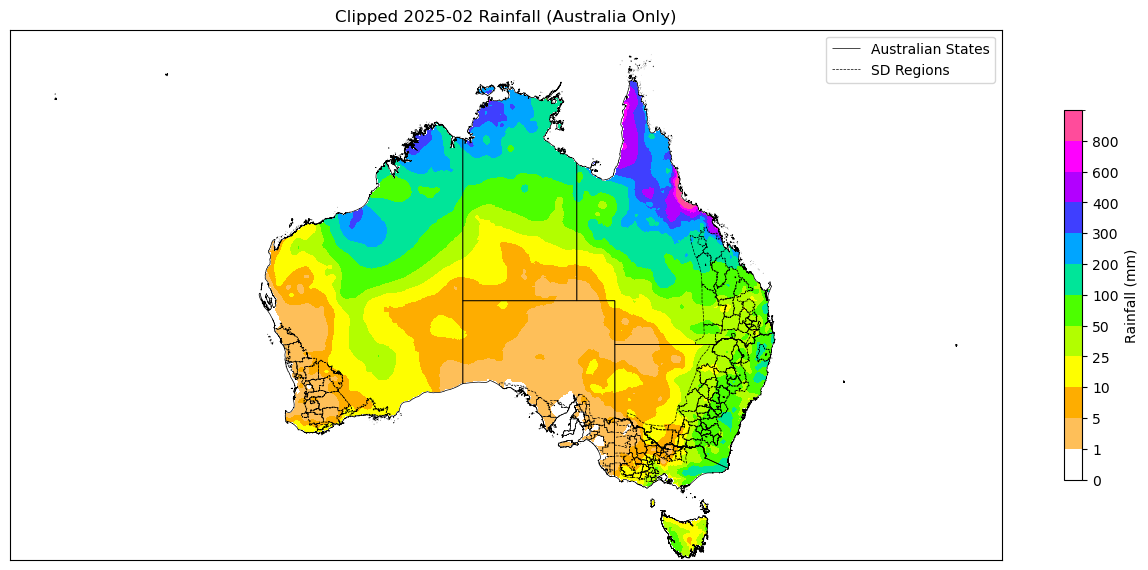

In [35]:
import os
import rasterio
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import pandas as pd
import re
from rasterio.mask import mask

# Paths to vector data
states_shp = "/home/roddyb/projects/wheatbelt_rainfall_analyser/data/external/shapefiles/STE_2021_AUST_GDA2020/STE_2021_AUST_GDA2020.shp"
sd_regions_shp = "/home/roddyb/projects/wheatbelt_rainfall_analyser/data/external/shapefiles/Australia_SA2_Wheat_clipped/Australia_SA2_Wheat_clipped.shp"

# Detect latest GeoTIFF file dynamically from data/interim
interim_dir = "/home/roddyb/projects/wheatbelt_rainfall_analyser/data/interim"
latest_geotiff = None
latest_month = None

for file in os.listdir(interim_dir):
    match = re.search(r'(\d{4}-\d{2})_BOM_monthly_rain\.tif', file)
    if match:
        latest_geotiff = os.path.join(interim_dir, file)
        latest_month = match.group(1)  # Extract YYYY-MM

if latest_geotiff is None:
    raise FileNotFoundError("No valid GeoTIFF found in interim directory!")

print(f"Processing: {latest_geotiff}")

# Load Australian states shapefile
australia_shape = gpd.read_file(states_shp)

# Drop empty geometries explicitly
australia_shape = australia_shape[~australia_shape.geometry.is_empty & australia_shape.geometry.notnull()]

# Open GeoTIFF and Get CRS
with rasterio.open(latest_geotiff) as src:
    raster_crs = src.crs
    raster_bounds = src.bounds

# **🔹 Fix CRS Issues: Ensure Shapefiles Match Raster CRS**
def fix_crs(shapefile_path, target_crs):
    """Loads a shapefile and reprojects it to match the raster CRS."""
    shp = gpd.read_file(shapefile_path)
    
    # Check if CRS exists, if not assume GDA2020 (EPSG:7844)
    if shp.crs is None:
        print(f"WARNING: {shapefile_path} has no CRS. Assigning EPSG:7844 (GDA2020).")
        shp = shp.set_crs("EPSG:7844")

    # Reproject if CRS does not match raster
    if shp.crs != target_crs:
        shp = shp.to_crs(target_crs)
        print(f"Reprojected {shapefile_path} to {target_crs}.")
    
    return shp

# Reproject shapefiles to match raster CRS
states = fix_crs(states_shp, raster_crs)
sd_regions = fix_crs(sd_regions_shp, raster_crs)

# **🔹 Clip Raster Using Australian Boundary**
with rasterio.open(latest_geotiff) as src:
    shapes = [geom for geom in australia_shape.geometry.__geo_interface__['features']]
    shapes = [feature["geometry"] for feature in shapes if feature["geometry"] is not None]

    # Mask raster to keep only values inside the Australian boundary
    out_image, out_transform = mask(src, shapes, crop=True, nodata=np.nan)
    out_meta = src.meta.copy()
    
    # **Fix the shape issue by squeezing the extra dimension**
    out_image = np.squeeze(out_image)  # Ensures correct (height, width) format

    # Update metadata for clipped raster
    out_meta.update({
        "driver": "GTiff",
        "height": out_image.shape[0],
        "width": out_image.shape[1],
        "transform": out_transform,
        "nodata": np.nan
    })

# Save clipped raster
clipped_tif_path = latest_geotiff.replace('.tif', '_clipped.tif')
with rasterio.open(clipped_tif_path, "w", **out_meta) as dest:
    dest.write(out_image, 1)  # Correct shape now

print(f"Clipped raster saved as: {clipped_tif_path}")

# **🔹 Load and Apply Custom Colormap from CSV**
csv_colormap_path = "/home/roddyb/projects/wheatbelt_rainfall_analyser/data/colormaps/unique_rgb_colors.csv"

# Load the unique RGB values from CSV
df = pd.read_csv(csv_colormap_path)

# Define the boundaries based on rainfall intervals
boundaries = np.append(df["Rainfall"].values, df["Rainfall"].values[-1] + 1)

# Create a list of colors from the RGB values (scaled to 0-1 range)
colors = list(zip(df["R"] / 255.0, df["G"] / 255.0, df["B"] / 255.0))

# Create a ListedColormap for discrete colors
cmap = mcolors.ListedColormap(colors)

# Create the norm with boundaries
norm = mcolors.BoundaryNorm(boundaries, cmap.N)

# **🔹 Visualization with Custom Colormap**
fig, ax = plt.subplots(figsize=(16, 12))

with rasterio.open(clipped_tif_path) as clipped_src:
    rainfall_data = clipped_src.read(1)
    rainfall_data = np.ma.masked_invalid(rainfall_data)  # Ensure NoData values are transparent
    extent = [clipped_src.bounds.left, clipped_src.bounds.right, clipped_src.bounds.bottom, clipped_src.bounds.top]

    img = ax.imshow(rainfall_data, cmap=cmap, norm=norm, extent=extent, origin='upper')
    
    # Remove lat/lon tick labels
ax.set_xticks([])
ax.set_yticks([])
ax.set_xticklabels([])
ax.set_yticklabels([])


# Overlay state and SD region boundaries
states.boundary.plot(ax=ax, edgecolor="black", linewidth=0.5, label="Australian States")
sd_regions.boundary.plot(ax=ax, edgecolor="black", linewidth=0.5, linestyle="dashed", label="SD Regions")

# Add colorbar
cbar = plt.colorbar(img, ax=ax, orientation='vertical', ticks=df["Rainfall"], shrink=0.4, aspect=20)
cbar.set_label("Rainfall (mm)")

plt.title(f"Clipped {latest_month} Rainfall (Australia Only)")
plt.legend()
plt.show()

